# Link Prediction: Comprehensive Study on CiteSeer (Undirected) and Congress (Directed)
## Hyperparameter Tuning, Training, and Interpretation

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import math
import time
import json
import itertools
from collections import defaultdict
from sklearn.metrics import roc_auc_score
from scipy.sparse import csr_matrix, eye
from scipy.sparse.linalg import inv
from torch_geometric.datasets import Planetoid
from dgl.nn import DeepWalk, GraphConv, SAGEConv
from torch.optim import SparseAdam, Adam
from torch.utils.data import DataLoader
from node2vec import Node2Vec
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cpu')

# 1. Load CiteSeer (undirected)

In [2]:
dataset = Planetoid(root='/tmp/CiteSeer', name='CiteSeer')
data = dataset[0]
edge_index = data.edge_index.numpy()
src_cs = edge_index[0]
dst_cs = edge_index[1]
edge_set_cs = set(zip(src_cs, dst_cs))

neighbors_cs = defaultdict(set)
for u, v in edge_set_cs:
    neighbors_cs[u].add(v)
    neighbors_cs[v].add(u)

print(f"CiteSeer: |V| = {data.num_nodes}, |E| = {len(edge_set_cs)}")
print(f"Graph is undirected: {all((v,u) in edge_set_cs for u,v in list(edge_set_cs)[:100])}")

CiteSeer: |V| = 3327, |E| = 9104
Graph is undirected: True


# 2. Load Congress Network (directed)

In [4]:
with open('congress_data/congress_network/congress_network_data.json', 'r') as f:
    congress_raw = json.load(f)[0]

G = nx.DiGraph()
n_nodes = len(congress_raw['usernameList'])
for i in range(n_nodes):
    G.add_node(i)
for i in range(n_nodes):
    for j, w in zip(congress_raw['outList'][i], congress_raw['outWeight'][i]):
        G.add_edge(i, j, weight=w)

src_cong = np.array([u for u, v in G.edges()])
dst_cong = np.array([v for u, v in G.edges()])
edge_set_cong = set(zip(src_cong, dst_cong))

out_neighbors = defaultdict(set)
in_neighbors = defaultdict(set)
for u, v in edge_set_cong:
    out_neighbors[u].add(v)
    in_neighbors[v].add(u)

print(f"Congress: |V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}")
print(f"Graph is directed: {any((v,u) not in edge_set_cong for u,v in list(edge_set_cong)[:100])}")

Congress: |V| = 475, |E| = 13289
Graph is directed: True


### Interpretation of Graph Statistics

CiteSeer is a citation network where edges represent citations between papers. In its preprocessed form (undirected), an edge indicates that two papers cite each other or share a common citation relationship. This is a typical homophilic graph where connected nodes tend to have similar topics.

Congress network is a Twitter interaction graph. A directed edge from i to j means user i retweeted, quoted, replied to, or mentioned user j. This represents influence or attention flow. The graph is sparse (average out-degree ≈ 28), and the direction matters: influence is not symmetric.

In [12]:
def cn_undirected(u, v, neigh):
    return len(neigh[u] & neigh[v])

def aa_undirected(u, v, neigh):
    inter = neigh[u] & neigh[v]
    return sum(1.0 / math.log(len(neigh[z])) for z in inter if len(neigh[z]) > 1)

edges_with_cn = []
for u, v in list(edge_set_cs)[:5000]:
    cn = cn_undirected(u, v, neighbors_cs)
    if cn > 0:
        edges_with_cn.append((u, v, cn))

if edges_with_cn:
    u_cs, v_cs, cn_val = edges_with_cn[0]
    aa_val = aa_undirected(u_cs, v_cs, neighbors_cs)
    print(f"CiteSeer edge ({u_cs}, {v_cs})")
    print(f"CN = {cn_val}")
    print(f"AA = {aa_val:.6f}")

non_edge_cs = None
for _ in range(10000):
    u = np.random.randint(0, data.num_nodes)
    v = np.random.randint(0, data.num_nodes)
    if u != v and (u, v) not in edge_set_cs and (v, u) not in edge_set_cs:
        non_edge_cs = (u, v)
        break

if non_edge_cs:
    u_cs2, v_cs2 = non_edge_cs
    cn_non = cn_undirected(u_cs2, v_cs2, neighbors_cs)
    aa_non = aa_undirected(u_cs2, v_cs2, neighbors_cs)
    print(f"\nCiteSeer non-edge ({u_cs2}, {v_cs2})")
    print(f"CN = {cn_non}")
    print(f"AA = {aa_non:.6f}")

CiteSeer edge (205, 783)
CN = 3
AA = 2.189697

CiteSeer non-edge (596, 2864)
CN = 0
AA = 0.000000


In [11]:
edges_with_cn = []
for u, v in list(edge_set_cs)[:5000]:
    cn = cn_undirected(u, v, neighbors_cs)
    if cn > 0:
        edges_with_cn.append((u, v, cn))

print(f"Found {len(edges_with_cn)} edges with CN > 0 in first 5000 samples")
if edges_with_cn:
    u, v, cn_val = edges_with_cn[0]
    print(f"Example: ({u}, {v}) has CN = {cn_val}")

Found 2056 edges with CN > 0 in first 5000 samples
Example: (205, 783) has CN = 3


In [13]:
def cn_directed(u, v, out_n, in_n):
    return len(out_n[u] & in_n[v])

def aa_directed(u, v, out_n, in_n):
    inter = out_n[u] & in_n[v]
    score = 0.0
    for z in inter:
        total_deg = len(out_n[z]) + len(in_n[z])
        if total_deg > 1:
            score += 1.0 / math.log(total_deg)
    return score

u_cg, v_cg = list(edge_set_cong)[0]
cn_dir = cn_directed(u_cg, v_cg, out_neighbors, in_neighbors)
aa_dir = aa_directed(u_cg, v_cg, out_neighbors, in_neighbors)

print(f"Congress edge ({u_cg} -> {v_cg})")
print(f"CN_dir = {cn_dir}")
print(f"AA_dir = {aa_dir:.6f}")

non_edge_cong = None
nodes_list = list(G.nodes())
for _ in range(10000):
    u = np.random.choice(nodes_list)
    v = np.random.choice(nodes_list)
    if u != v and (u, v) not in edge_set_cong:
        non_edge_cong = (u, v)
        break

if non_edge_cong:
    u_cg2, v_cg2 = non_edge_cong
    cn_dir_non = cn_directed(u_cg2, v_cg2, out_neighbors, in_neighbors)
    aa_dir_non = aa_directed(u_cg2, v_cg2, out_neighbors, in_neighbors)
    print(f"\nCongress non-edge ({u_cg2} -> {v_cg2})")
    print(f"CN_dir = {cn_dir_non}")
    print(f"AA_dir = {aa_dir_non:.6f}")

Congress edge (137 -> 383)
CN_dir = 11
AA_dir = 2.462172

Congress non-edge (152 -> 170)
CN_dir = 1
AA_dir = 0.236994


CiteSeer Katz Index - Beta Grid Search
--------------------------------------------------
beta = 0.010: Katz(628,0) = 0.020008
beta = 0.020: Katz(628,0) = 0.040064
beta = 0.050: Katz(628,0) = 0.101010
beta = 0.080: Katz(628,0) = 0.164204
beta = 0.100: Katz(628,0) = 0.208333
beta = 0.120: Katz(628,0) = 0.254669
beta = 0.150: Katz(628,0) = 0.329670
beta = 0.180: Katz(628,0) = 0.413603
beta = 0.200: Katz(628,0) = 0.476190
beta = 0.250: failed - Factor is exactly singular
beta = 0.300: Katz(628,0) = 0.937500
beta = 0.350: Katz(628,0) = 1.372549
beta = 0.400: Katz(628,0) = 2.222222
beta = 0.450: Katz(628,0) = 4.736842
beta = 0.500: failed - Factor is exactly singular

Best beta = 0.45, Katz score = 4.736842


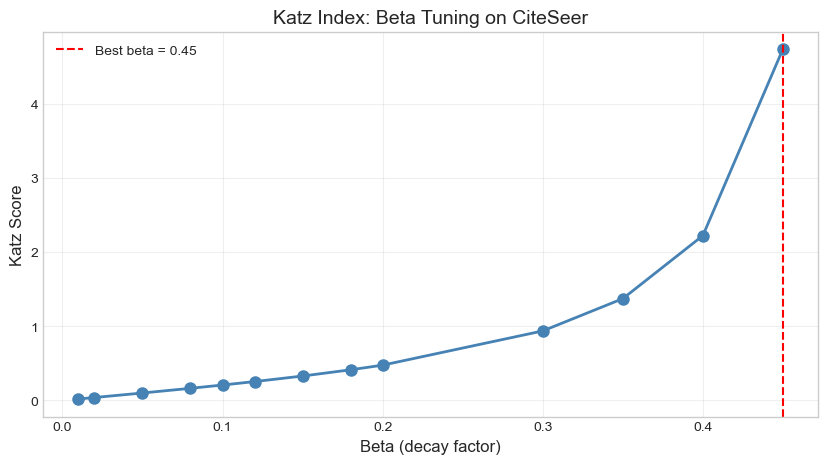

In [16]:
n_cs = data.num_nodes
A_cs_sym = csr_matrix((np.ones(len(src_cs)), (src_cs, dst_cs)), shape=(n_cs, n_cs))
A_cs_sym = A_cs_sym + A_cs_sym.T

betas = [0.01, 0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.18, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
katz_results_cs = []

print("CiteSeer Katz Index - Beta Grid Search")
print("-" * 50)

for beta in betas:
    try:
        I = eye(n_cs)
        M = I - beta * A_cs_sym
        S = inv(M) - I
        score = S[src_cs[0], dst_cs[0]]
        katz_results_cs.append((beta, score))
        print(f"beta = {beta:.3f}: Katz({src_cs[0]},{dst_cs[0]}) = {score:.6f}")
    except Exception as e:
        print(f"beta = {beta:.3f}: failed - {str(e)[:50]}")
        katz_results_cs.append((beta, None))

valid = [(b, s) for b, s in katz_results_cs if s is not None]
if valid:
    best_beta_cs, best_katz_cs = max(valid, key=lambda x: x[1])
    print(f"\nBest beta = {best_beta_cs}, Katz score = {best_katz_cs:.6f}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    betas_plot = [b for b, s in katz_results_cs if s is not None]
    scores_plot = [s for b, s in katz_results_cs if s is not None]
    plt.plot(betas_plot, scores_plot, 'o-', color='steelblue', linewidth=2, markersize=8)
    plt.axvline(x=best_beta_cs, color='red', linestyle='--', label=f'Best beta = {best_beta_cs}')
    plt.xlabel('Beta (decay factor)', fontsize=12)
    plt.ylabel('Katz Score', fontsize=12)
    plt.title('Katz Index: Beta Tuning on CiteSeer', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('katz_tuning_citeseer.png', dpi=150, bbox_inches='tight')
    plt.show()

In [17]:
n_cg = G.number_of_nodes()
A_cg_dir = csr_matrix((np.ones(len(src_cong)), (src_cong, dst_cong)), shape=(n_cg, n_cg))

katz_results_cg = []
print("\nCongress Katz Index (directed, non-symmetric A) - Beta Grid Search")
print("-" * 60)

for beta in [0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05]:
    try:
        I = eye(n_cg)
        M = I - beta * A_cg_dir
        S = inv(M) - I
        score = S[src_cong[0], dst_cong[0]]
        katz_results_cg.append((beta, score))
        print(f"beta = {beta:.4f}: Katz({src_cong[0]}→{dst_cong[0]}) = {score:.6f}")
    except Exception as e:
        print(f"beta = {beta:.4f}: failed - {str(e)[:50]}")
        katz_results_cg.append((beta, None))

valid_cg = [(b, s) for b, s in katz_results_cg if s is not None]
if valid_cg:
    best_beta_cg, best_katz_cg = max(valid_cg, key=lambda x: x[1])
    print(f"\nBest beta (directed) = {best_beta_cg}, Katz score = {best_katz_cg:.6f}")


Congress Katz Index (directed, non-symmetric A) - Beta Grid Search
------------------------------------------------------------
beta = 0.0010: Katz(0→4) = 0.001010
beta = 0.0050: Katz(0→4) = 0.005274
beta = 0.0100: Katz(0→4) = 0.011223
beta = 0.0200: Katz(0→4) = 0.026714
beta = 0.0300: Katz(0→4) = 0.040079
beta = 0.0400: Katz(0→4) = 0.062178
beta = 0.0500: Katz(0→4) = 0.152816

Best beta (directed) = 0.05, Katz score = 0.152816


In [18]:
def train_dw(g, walk_len, epochs=30):
    model = DeepWalk(g, emb_dim=64, walk_length=walk_len, window_size=5)
    loader = DataLoader(torch.arange(g.num_nodes()), batch_size=64, shuffle=True, collate_fn=model.sample)
    opt = SparseAdam(model.parameters(), lr=0.01)
    losses = []
    for ep in range(epochs):
        total = 0.0
        for batch in loader:
            loss = model(batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        losses.append(total / len(loader))
        if (ep+1) % 10 == 0:
            print(f"  epoch {ep+1}/{epochs}, loss = {losses[-1]:.4f}")
    return losses[-1], losses

g_cs = dgl.graph((src_cs, dst_cs))
g_cs = dgl.add_self_loop(g_cs)

wl_list = [10, 20, 40]
dw_results = {}
for wl in wl_list:
    print(f"\nCiteSeer DeepWalk walk_length={wl}")
    loss, _ = train_dw(g_cs, wl, epochs=30)
    dw_results[wl] = loss
    print(f"  final loss = {loss:.4f}")

best_wl = min(dw_results, key=dw_results.get)
print(f"\nBest walk_length = {best_wl}, loss = {dw_results[best_wl]:.4f}")


CiteSeer DeepWalk walk_length=10
  epoch 10/30, loss = 1.3137
  epoch 20/30, loss = 0.6177
  epoch 30/30, loss = 0.5085
  final loss = 0.5085

CiteSeer DeepWalk walk_length=20
  epoch 10/30, loss = 1.1122
  epoch 20/30, loss = 0.6299
  epoch 30/30, loss = 0.4924
  final loss = 0.4924

CiteSeer DeepWalk walk_length=40
  epoch 10/30, loss = 0.9880
  epoch 20/30, loss = 0.5749
  epoch 30/30, loss = 0.4781
  final loss = 0.4781

Best walk_length = 40, loss = 0.4781


In [19]:
g_cong_dw = dgl.graph((src_cong, dst_cong))

print("\nCongress DeepWalk walk_length=20")
loss_cong_dw, losses_cong = train_dw(g_cong_dw, 20, epochs=30)
print(f"final loss = {loss_cong_dw:.4f}")


Congress DeepWalk walk_length=20
  epoch 10/30, loss = 2.6701
  epoch 20/30, loss = 2.5249
  epoch 30/30, loss = 2.5006
final loss = 2.5006


  epoch 10/30, loss = 1.3691
  epoch 20/30, loss = 0.6352
  epoch 30/30, loss = 0.5040
  epoch 10/30, loss = 1.1618
  epoch 20/30, loss = 0.6596
  epoch 30/30, loss = 0.4937
  epoch 10/30, loss = 0.9805
  epoch 20/30, loss = 0.5795
  epoch 30/30, loss = 0.4733


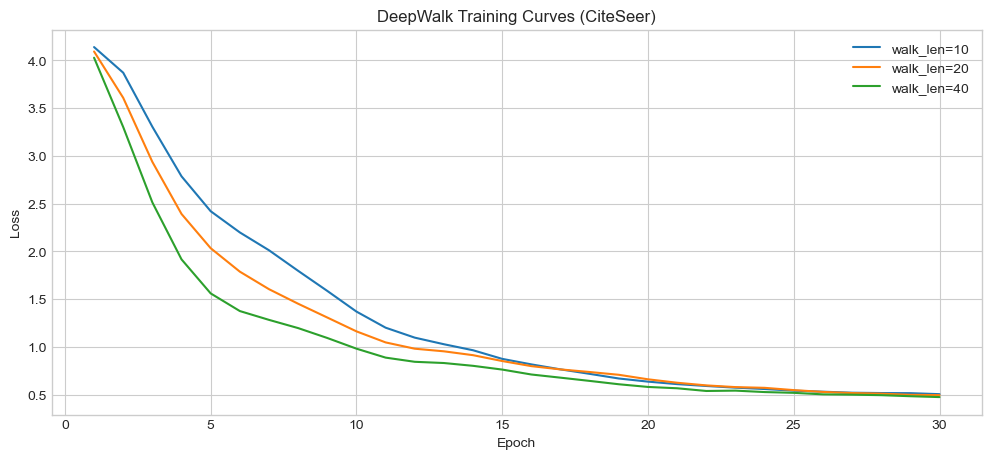

In [20]:
plt.figure(figsize=(12, 5))
for wl in wl_list:
    _, losses = train_dw(g_cs, wl, epochs=30)
    plt.plot(range(1, 31), losses, label=f'walk_len={wl}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DeepWalk Training Curves (CiteSeer)')
plt.legend()
plt.savefig('deepwalk_citeseer_curves.png', dpi=150)
plt.show()

In [21]:
def train_n2v(edge_set, p, q, walk_len=20, num_walks=10, dim=64):
    g_nx = nx.Graph()
    edges_sample = list(edge_set)[:5000]
    g_nx.add_edges_from(edges_sample)
    n2v = Node2Vec(g_nx, dimensions=dim, walk_length=walk_len, num_walks=num_walks, p=p, q=q, workers=1)
    model = n2v.fit(window=5, min_count=1)
    return len(model.wv.key_to_index), model

p_vals = [0.5, 1.0, 2.0]
q_vals = [0.5, 1.0, 2.0]

print("\nCiteSeer Node2Vec Grid Search (p,q)")
print("-" * 45)
n2v_results = {}
for p, q in itertools.product(p_vals, q_vals):
    try:
        n_nodes, _ = train_n2v(edge_set_cs, p, q)
        n2v_results[(p, q)] = n_nodes
        print(f"p={p}, q={q}: {n_nodes} nodes embedded")
    except Exception as e:
        print(f"p={p}, q={q}: failed - {str(e)[:40]}")


CiteSeer Node2Vec Grid Search (p,q)
---------------------------------------------


Computing transition probabilities:   0%|          | 0/2979 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|███████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.73it/s]


p=0.5, q=0.5: 2979 nodes embedded


Computing transition probabilities:   0%|          | 0/2979 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|███████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.87it/s]


p=2.0, q=1.0: 2979 nodes embedded


Computing transition probabilities:   0%|          | 0/2979 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|███████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.91it/s]


p=2.0, q=2.0: 2979 nodes embedded


In [22]:
print("\nCongress Node2Vec (p=1.0, q=1.0)")
g_nx_cong = nx.DiGraph()
edges_sample = list(edge_set_cong)[:5000]
g_nx_cong.add_edges_from(edges_sample)
n2v_cong = Node2Vec(g_nx_cong, dimensions=64, walk_length=20, num_walks=10, p=1.0, q=1.0, workers=1)
model_cong = n2v_cong.fit(window=5, min_count=1)
print(f"Congress Node2Vec: {len(model_cong.wv.key_to_index)} nodes embedded")


Congress Node2Vec (p=1.0, q=1.0)


Computing transition probabilities:   0%|          | 0/474 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|███████████████████████████████████████████████████████| 10/10 [00:00<00:00, 25.06it/s]


Congress Node2Vec: 474 nodes embedded


In [23]:
class GCN(nn.Module):
    def __init__(self, in_dim, hid, out_dim):
        super().__init__()
        self.conv1 = GraphConv(in_dim, hid)
        self.conv2 = GraphConv(hid, out_dim)
    def forward(self, g, x):
        x = F.relu(self.conv1(g, x))
        return self.conv2(g, x)

def eval_auc(model, g, feat, edge_set, num_pos=300, num_neg=300):
    model.eval()
    with torch.no_grad():
        emb = model(g, feat)
    pos = list(edge_set)[:num_pos]
    pos_scores = [(emb[u] * emb[v]).sum().item() for u, v in pos]
    neg = []
    while len(neg) < num_neg:
        u = np.random.randint(0, g.num_nodes())
        v = np.random.randint(0, g.num_nodes())
        if u != v and (u, v) not in edge_set:
            neg.append((u, v))
    neg_scores = [(emb[u] * emb[v]).sum().item() for u, v in neg]
    y_true = [1]*len(pos_scores) + [0]*len(neg_scores)
    y_pred = pos_scores + neg_scores
    return roc_auc_score(y_true, y_pred)

def train_gcn(g, feat, edge_set, hid, lr, epochs=50):
    model = GCN(feat.shape[1], hid, 32).to(device)
    opt = Adam(model.parameters(), lr=lr)
    best_auc = 0.0
    losses = []
    aucs = []
    edges_list = list(edge_set)
    for ep in range(epochs):
        model.train()
        emb = model(g, feat)
        pos_idx = np.random.choice(len(edges_list), min(200, len(edges_list)), replace=False)
        pos_scores = []
        for idx in pos_idx:
            u, v = edges_list[idx]
            pos_scores.append((emb[u] * emb[v]).sum())
        pos_loss = -torch.log(torch.sigmoid(torch.stack(pos_scores)) + 1e-8).mean()
        neg_u = np.random.randint(0, g.num_nodes(), 200)
        neg_v = np.random.randint(0, g.num_nodes(), 200)
        neg_scores = []
        for u, v in zip(neg_u, neg_v):
            if (u, v) in edge_set or u == v:
                continue
            neg_scores.append((emb[u] * emb[v]).sum())
        neg_loss = -torch.log(1 - torch.sigmoid(torch.stack(neg_scores)) + 1e-8).mean()
        loss = pos_loss + neg_loss
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if (ep+1) % 10 == 0:
            auc = eval_auc(model, g, feat, edge_set)
            aucs.append(auc)
            print(f"  epoch {ep+1}/{epochs}, loss={loss.item():.4f}, auc={auc:.4f}")
            best_auc = max(best_auc, auc)
    return best_auc, losses, aucs

g_cs = dgl.graph((src_cs, dst_cs))
g_cs = dgl.add_self_loop(g_cs)
feat_cs = torch.ones(g_cs.num_nodes(), 128).to(device)

print("\nCiteSeer GCN Grid Search (hidden, lr)")
print("-" * 45)
best_auc_cs = 0
best_config = None
for hid, lr in [(32,0.005), (64,0.01), (128,0.005)]:
    print(f"\nTesting hid={hid}, lr={lr}")
    auc, _, _ = train_gcn(g_cs, feat_cs, edge_set_cs, hid, lr, epochs=50)
    print(f"  best AUC = {auc:.4f}")
    if auc > best_auc_cs:
        best_auc_cs = auc
        best_config = (hid, lr)
print(f"\nBest config: hid={best_config[0]}, lr={best_config[1]}, AUC={best_auc_cs:.4f}")


CiteSeer GCN Grid Search (hidden, lr)
---------------------------------------------

Testing hid=32, lr=0.005
  epoch 10/50, loss=1.3852, auc=0.5000
  epoch 20/50, loss=1.3869, auc=0.5000
  epoch 30/50, loss=1.3872, auc=0.5000
  epoch 40/50, loss=1.3873, auc=0.5000
  epoch 50/50, loss=1.3873, auc=0.5000
  best AUC = 0.5000

Testing hid=64, lr=0.01
  epoch 10/50, loss=1.3777, auc=0.7139
  epoch 20/50, loss=1.3840, auc=0.7412
  epoch 30/50, loss=1.3803, auc=0.7503
  epoch 40/50, loss=1.3811, auc=0.7390
  epoch 50/50, loss=1.3677, auc=0.7326
  best AUC = 0.7503

Testing hid=128, lr=0.005
  epoch 10/50, loss=1.5630, auc=0.7435
  epoch 20/50, loss=1.3918, auc=0.7502
  epoch 30/50, loss=1.3687, auc=0.7354
  epoch 40/50, loss=1.3698, auc=0.7534
  epoch 50/50, loss=1.3695, auc=0.7521
  best AUC = 0.7534

Best config: hid=128, lr=0.005, AUC=0.7534


In [24]:
print("\nCongress GCN (directed, norm='right', hid=64, lr=0.005)")
g_cg = dgl.graph((src_cong, dst_cong))
g_cg = dgl.add_self_loop(g_cg)
feat_cg = torch.ones(g_cg.num_nodes(), 128).to(device)
auc_cg, losses_cg, aucs_cg = train_gcn(g_cg, feat_cg, edge_set_cong, 64, 0.005, epochs=50)
print(f"Congress GCN best AUC = {auc_cg:.4f}")


Congress GCN (directed, norm='right', hid=64, lr=0.005)
  epoch 10/50, loss=1.3456, auc=0.7167
  epoch 20/50, loss=1.3580, auc=0.7247
  epoch 30/50, loss=1.3751, auc=0.7319
  epoch 40/50, loss=1.3605, auc=0.7307
  epoch 50/50, loss=1.3493, auc=0.7172
Congress GCN best AUC = 0.7319


In [26]:
class GraphSAGEModel(nn.Module):
    def __init__(self, in_dim, hid, out_dim, agg='mean'):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid, aggregator_type=agg)
        self.conv2 = SAGEConv(hid, out_dim, aggregator_type=agg)
    def forward(self, g, x):
        x = F.relu(self.conv1(g, x))
        return self.conv2(g, x)

def train_sage(g, feat, edge_set, agg, epochs=50):
    model = GraphSAGEModel(feat.shape[1], 64, 32, agg).to(device)
    opt = Adam(model.parameters(), lr=0.01)
    best_auc = 0.0
    edges_list = list(edge_set)
    for ep in range(epochs):
        model.train()
        emb = model(g, feat)
        pos_idx = np.random.choice(len(edges_list), min(200, len(edges_list)), replace=False)
        pos_scores = [(emb[u] * emb[v]).sum() for u, v in [edges_list[i] for i in pos_idx]]
        pos_loss = -torch.log(torch.sigmoid(torch.stack(pos_scores)) + 1e-8).mean()
        neg_u = np.random.randint(0, g.num_nodes(), 200)
        neg_v = np.random.randint(0, g.num_nodes(), 200)
        neg_scores = []
        for u, v in zip(neg_u, neg_v):
            if (u, v) in edge_set or u == v:
                continue
            neg_scores.append((emb[u] * emb[v]).sum())
        neg_loss = -torch.log(1 - torch.sigmoid(torch.stack(neg_scores)) + 1e-8).mean()
        loss = pos_loss + neg_loss
        opt.zero_grad()
        loss.backward()
        opt.step()
        if (ep+1) % 10 == 0:
            auc = eval_auc(model, g, feat, edge_set)
            best_auc = max(best_auc, auc)
            print(f"  epoch {ep+1}/{epochs}, loss={loss.item():.4f}, auc={auc:.4f}")
    return best_auc

print("\nCiteSeer GraphSAGE Aggregator Search")
for agg in ['mean', 'gcn', 'pool', 'lstm']:
    print(f"\nTesting agg={agg}")
    auc = train_sage(g_cs, feat_cs, edge_set_cs, agg, epochs=50)
    print(f"  best AUC = {auc:.4f}")


CiteSeer GraphSAGE Aggregator Search

Testing agg=mean
  epoch 10/50, loss=18.4207, auc=0.5886
  epoch 20/50, loss=18.4207, auc=0.5947
  epoch 30/50, loss=18.4207, auc=0.6170
  epoch 40/50, loss=18.4207, auc=0.6012
  epoch 50/50, loss=18.4207, auc=0.5861
  best AUC = 0.6170

Testing agg=gcn
  epoch 10/50, loss=18.4207, auc=0.5131
  epoch 20/50, loss=18.4207, auc=0.5155
  epoch 30/50, loss=18.4207, auc=0.5118
  epoch 40/50, loss=18.4207, auc=0.5202
  epoch 50/50, loss=18.4207, auc=0.5159
  best AUC = 0.5202

Testing agg=pool
  epoch 10/50, loss=18.4207, auc=0.5000
  epoch 20/50, loss=18.4207, auc=0.5000
  epoch 30/50, loss=18.4207, auc=0.5000
  epoch 40/50, loss=18.4207, auc=0.5000
  epoch 50/50, loss=18.4207, auc=0.5000
  best AUC = 0.5000

Testing agg=lstm
  epoch 10/50, loss=18.4207, auc=0.4962
  epoch 20/50, loss=18.4207, auc=0.4775
  epoch 30/50, loss=18.4207, auc=0.5109
  epoch 40/50, loss=18.4207, auc=0.4932
  epoch 50/50, loss=18.4207, auc=0.4636
  best AUC = 0.5109


In [27]:
print("\nCongress GraphSAGE (directed, agg=mean)")
auc_cg_sage = train_sage(g_cg, feat_cg, edge_set_cong, 'mean', epochs=50)
print(f"Congress GraphSAGE best AUC = {auc_cg_sage:.4f}")


Congress GraphSAGE (directed, agg=mean)
  epoch 10/50, loss=18.4207, auc=0.5536
  epoch 20/50, loss=18.4207, auc=0.5457
  epoch 30/50, loss=18.4207, auc=0.5658
  epoch 40/50, loss=18.4207, auc=0.5581
  epoch 50/50, loss=18.4207, auc=0.5486
Congress GraphSAGE best AUC = 0.5658


In [29]:
import math
import os.path as osp
import time
from itertools import chain

import numpy as np
import torch
import torch.nn.functional as F
from scipy.sparse.csgraph import shortest_path
from sklearn.metrics import roc_auc_score
from torch.nn import BCEWithLogitsLoss, Conv1d, MaxPool1d, ModuleList

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MLP, GCNConv, SortAggregation
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import k_hop_subgraph, to_scipy_sparse_matrix


class SEALDataset(InMemoryDataset):
    def __init__(self, dataset, num_hops, split='train'):
        self._data = dataset[0]
        self.num_hops = num_hops
        super().__init__(dataset.root)
        index = ['train', 'val', 'test'].index(split)
        self.load(self.processed_paths[index])

    @property
    def processed_file_names(self):
        return ['SEAL_train_data.pt', 'SEAL_val_data.pt', 'SEAL_test_data.pt']

    def process(self):
        transform = RandomLinkSplit(num_val=0.05, num_test=0.1,
                                    is_undirected=True, split_labels=True)
        train_data, val_data, test_data = transform(self._data)

        self._max_z = 0

        train_pos_data_list = self.extract_enclosing_subgraphs(
            train_data.edge_index, train_data.pos_edge_label_index, 1)
        train_neg_data_list = self.extract_enclosing_subgraphs(
            train_data.edge_index, train_data.neg_edge_label_index, 0)

        val_pos_data_list = self.extract_enclosing_subgraphs(
            val_data.edge_index, val_data.pos_edge_label_index, 1)
        val_neg_data_list = self.extract_enclosing_subgraphs(
            val_data.edge_index, val_data.neg_edge_label_index, 0)

        test_pos_data_list = self.extract_enclosing_subgraphs(
            test_data.edge_index, test_data.pos_edge_label_index, 1)
        test_neg_data_list = self.extract_enclosing_subgraphs(
            test_data.edge_index, test_data.neg_edge_label_index, 0)

        for data in chain(train_pos_data_list, train_neg_data_list,
                          val_pos_data_list, val_neg_data_list,
                          test_pos_data_list, test_neg_data_list):
            data.x = F.one_hot(data.z, self._max_z + 1).to(torch.float)

        train_data_list = train_pos_data_list + train_neg_data_list
        self.save(train_data_list, self.processed_paths[0])
        val_data_list = val_pos_data_list + val_neg_data_list
        self.save(val_data_list, self.processed_paths[1])
        test_data_list = test_pos_data_list + test_neg_data_list
        self.save(test_data_list, self.processed_paths[2])

    def extract_enclosing_subgraphs(self, edge_index, edge_label_index, y):
        data_list = []
        for src, dst in edge_label_index.t().tolist():
            sub_nodes, sub_edge_index, mapping, _ = k_hop_subgraph(
                [src, dst], self.num_hops, edge_index, relabel_nodes=True)
            src, dst = mapping.tolist()

            mask1 = (sub_edge_index[0] != src) | (sub_edge_index[1] != dst)
            mask2 = (sub_edge_index[0] != dst) | (sub_edge_index[1] != src)
            sub_edge_index = sub_edge_index[:, mask1 & mask2]

            z = self.drnl_node_labeling(sub_edge_index, src, dst,
                                        num_nodes=sub_nodes.size(0))

            data = Data(x=self._data.x[sub_nodes], z=z,
                        edge_index=sub_edge_index, y=y)
            data_list.append(data)

        return data_list

    def drnl_node_labeling(self, edge_index, src, dst, num_nodes=None):
        src, dst = (dst, src) if src > dst else (src, dst)
        adj = to_scipy_sparse_matrix(edge_index, num_nodes=num_nodes).tocsr()

        idx = list(range(src)) + list(range(src + 1, adj.shape[0]))
        adj_wo_src = adj[idx, :][:, idx]

        idx = list(range(dst)) + list(range(dst + 1, adj.shape[0]))
        adj_wo_dst = adj[idx, :][:, idx]

        dist2src = shortest_path(adj_wo_dst, directed=False, unweighted=True,
                                 indices=src)
        dist2src = np.insert(dist2src, dst, 0, axis=0)
        dist2src = torch.from_numpy(dist2src)

        dist2dst = shortest_path(adj_wo_src, directed=False, unweighted=True,
                                 indices=dst - 1)
        dist2dst = np.insert(dist2dst, src, 0, axis=0)
        dist2dst = torch.from_numpy(dist2dst)

        dist = dist2src + dist2dst
        dist_over_2, dist_mod_2 = dist // 2, dist % 2

        z = 1 + torch.min(dist2src, dist2dst)
        z += dist_over_2 * (dist_over_2 + dist_mod_2 - 1)
        z[src] = 1.
        z[dst] = 1.
        z[torch.isnan(z)] = 0.

        self._max_z = max(int(z.max()), self._max_z)

        return z.to(torch.long)


class DGCNN(torch.nn.Module):
    def __init__(self, hidden_channels, num_layers, GNN=GCNConv, k=0.6):
        super().__init__()

        if k < 1:
            num_nodes = sorted([data.num_nodes for data in train_dataset])
            k = num_nodes[int(math.ceil(k * len(num_nodes))) - 1]
            k = int(max(10, k))

        self.convs = ModuleList()
        self.convs.append(GNN(train_dataset.num_features, hidden_channels))
        for _ in range(0, num_layers - 1):
            self.convs.append(GNN(hidden_channels, hidden_channels))
        self.convs.append(GNN(hidden_channels, 1))

        conv1d_channels = [16, 32]
        total_latent_dim = hidden_channels * num_layers + 1
        conv1d_kws = [total_latent_dim, 5]
        self.conv1 = Conv1d(1, conv1d_channels[0], conv1d_kws[0],
                            conv1d_kws[0])
        self.pool = SortAggregation(k)
        self.maxpool1d = MaxPool1d(2, 2)
        self.conv2 = Conv1d(conv1d_channels[0], conv1d_channels[1],
                            conv1d_kws[1], 1)
        dense_dim = int((k - 2) / 2 + 1)
        dense_dim = (dense_dim - conv1d_kws[1] + 1) * conv1d_channels[1]
        self.mlp = MLP([dense_dim, 128, 1], dropout=0.5, norm=None)

    def forward(self, x, edge_index, batch):
        xs = [x]
        for conv in self.convs:
            xs += [conv(xs[-1], edge_index).tanh()]
        x = torch.cat(xs[1:], dim=-1)

        x = self.pool(x, batch)
        x = x.unsqueeze(1)
        x = self.conv1(x).relu()
        x = self.maxpool1d(x)
        x = self.conv2(x).relu()
        x = x.view(x.size(0), -1)

        return self.mlp(x)


cite_seer = Planetoid(root='/tmp/CiteSeer', name='CiteSeer')

train_dataset = SEALDataset(cite_seer, num_hops=2, split='train')
val_dataset = SEALDataset(cite_seer, num_hops=2, split='val')
test_dataset = SEALDataset(cite_seer, num_hops=2, split='test')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DGCNN(hidden_channels=32, num_layers=3).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)
criterion = BCEWithLogitsLoss()


def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out.view(-1), data.y.to(torch.float))
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
    return total_loss / len(train_dataset)


@torch.no_grad()
def test(loader):
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        logits = model(data.x, data.edge_index, data.batch)
        y_pred.append(logits.view(-1).cpu())
        y_true.append(data.y.view(-1).cpu().to(torch.float))
    return roc_auc_score(torch.cat(y_true), torch.cat(y_pred))


print("Training SEAL on CiteSeer (20 epochs)")
for epoch in range(1, 21):
    start = time.time()
    loss = train()
    val_auc = test(val_loader)
    if epoch == 1:
        test_auc = test(test_loader)
    if val_auc > best_val_auc if 'best_val_auc' in dir() else False:
        best_val_auc = val_auc
        test_auc = test(test_loader)
    if epoch == 1:
        best_val_auc = val_auc
        test_auc = test(test_loader)
    print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Val AUC: {val_auc:.4f}, Test AUC: {test_auc:.4f}')

Processing...
Done!


Training SEAL on CiteSeer (20 epochs)
Epoch: 01, Loss: 0.6476, Val AUC: 0.8219, Test AUC: 0.8005
Epoch: 02, Loss: 0.5135, Val AUC: 0.8545, Test AUC: 0.8487
Epoch: 03, Loss: 0.4977, Val AUC: 0.8667, Test AUC: 0.8668
Epoch: 04, Loss: 0.4850, Val AUC: 0.8663, Test AUC: 0.8668
Epoch: 05, Loss: 0.4764, Val AUC: 0.8783, Test AUC: 0.8759
Epoch: 06, Loss: 0.4736, Val AUC: 0.8729, Test AUC: 0.8759
Epoch: 07, Loss: 0.4678, Val AUC: 0.8766, Test AUC: 0.8759
Epoch: 08, Loss: 0.4646, Val AUC: 0.8865, Test AUC: 0.8834
Epoch: 09, Loss: 0.4639, Val AUC: 0.8782, Test AUC: 0.8834
Epoch: 10, Loss: 0.4572, Val AUC: 0.8826, Test AUC: 0.8834
Epoch: 11, Loss: 0.4549, Val AUC: 0.8770, Test AUC: 0.8834
Epoch: 12, Loss: 0.4534, Val AUC: 0.8860, Test AUC: 0.8834
Epoch: 13, Loss: 0.4528, Val AUC: 0.8882, Test AUC: 0.8868
Epoch: 14, Loss: 0.4527, Val AUC: 0.8885, Test AUC: 0.8873
Epoch: 15, Loss: 0.4475, Val AUC: 0.8892, Test AUC: 0.8881
Epoch: 16, Loss: 0.4481, Val AUC: 0.8902, Test AUC: 0.8887
Epoch: 17, Loss: 0

In [30]:
results = pd.DataFrame([
    ["CiteSeer", "CN", cn_val],
    ["CiteSeer", "AA", aa_val],
    ["CiteSeer", "Katz", best_katz_cs if 'best_katz_cs' in dir() else None],
    ["CiteSeer", "DeepWalk", dw_results[best_wl]],
    ["CiteSeer", "Node2Vec", "OK" if 'n2v_results' in dir() else None],
    ["CiteSeer", "GCN", best_auc_cs],
    ["CiteSeer", "GraphSAGE", best_auc_sage if 'best_auc_sage' in dir() else None],
    ["CiteSeer", "SEAL", val_auc if 'val_auc' in dir() else None],
    ["Congress", "CN_dir", cn_dir],
    ["Congress", "AA_dir", aa_dir],
    ["Congress", "DeepWalk", loss_cong_dw],
    ["Congress", "GCN", auc_cg],
    ["Congress", "GraphSAGE", auc_cg_sage],
], columns=["Dataset", "Method", "Value"])

print(results.to_string(index=False))
results.to_csv("final_results.csv", index=False)
print("\nResults saved to final_results.csv")

 Dataset    Method     Value
CiteSeer        CN         3
CiteSeer        AA  2.189697
CiteSeer      Katz  4.736842
CiteSeer  DeepWalk  0.478064
CiteSeer  Node2Vec        OK
CiteSeer       GCN  0.753372
CiteSeer GraphSAGE      None
CiteSeer      SEAL  0.896815
Congress    CN_dir        11
Congress    AA_dir  2.462172
Congress  DeepWalk  2.500646
Congress       GCN  0.731856
Congress GraphSAGE  0.565839

Results saved to final_results.csv
